In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import coo_matrix, csr_matrix, eye as speye
from scipy.sparse.linalg import eigsh

In [17]:
# load and inspect
arr = np.load('data/node_features_topo.npy', allow_pickle=False)

print(f'shape: {arr.shape}')
print(f'dtype: {arr.dtype}')
print(f'nans:  {np.isnan(arr).sum()}')
print(f'infs:  {np.isinf(arr).sum()}')
print()

shape: (2041172, 6)
dtype: float32
nans:  0
infs:  0



In [6]:
col_labels = ['elevation','slope','aspect_sin','aspect_cos','curvature','log_acc']

print(f'{"Col":>4}  {"Feature":>12}  {"Min":>12}  {"Max":>12}  {"Mean":>12}  {"Std":>12}')
print('-' * 70)
for i, label in enumerate(col_labels):
    col = arr[:, i]
    print(f'{i:>4}  {label:>12}  {col.min():>12.4f}  {col.max():>12.4f}  {col.mean():>12.4f}  {col.std():>12.4f}')

 Col       Feature           Min           Max          Mean           Std
----------------------------------------------------------------------
   0     elevation      811.2109      987.2007      861.5251       38.7195
   1         slope        0.0178       82.3289       15.4682       10.0765
   2    aspect_sin       -1.0000        1.0000       -0.0190        0.7140
   3    aspect_cos       -1.0000        1.0000        0.1048        0.6920
   4     curvature       -0.1547        0.2178        0.0013        0.0543
   5       log_acc        0.6931       13.5554        2.2006        1.5978


In [7]:
# load and inspect index map
# note: gdalinfo reports width x height -- raster format
# array format is height (rows) x width (columns)

index_map = np.load('data/node_index_mosext.npy')

print(f'idx map shape: {index_map.shape}')
print(f'dtype:         {index_map.dtype}')
print()

nrows, ncols = index_map.shape
valid_mask   = index_map >= 0

print(f'full grid:     {nrows}x{ncols} = {nrows*ncols:,}')
print(f'valid pxls:    {valid_mask.sum():,}')
print(f'invalid (-1):  {(~valid_mask).sum():,}')
print(f'coverage:      {100 * valid_mask.sum() / (nrows*ncols):.1f}%')
print()

# confirm # valid pixels matches nodes in feature array
assert valid_mask.sum() == arr.shape[0], \
    f'mismatch: idx map has {valid_mask.sum()} val pixels but arr has {arr.shape[0]} nodes'
print('assertion passed: valid pixel count matches nodes in feature array')

idx map shape: (1875, 1957)
dtype:         int32

full grid:     1875x1957 = 3,669,375
valid pxls:    2,041,172
invalid (-1):  1,628,203
coverage:      55.6%

assertion passed: valid pixel count matches nodes in feature array


In [12]:
# gdalinfo reports (width, height) = (1957, 1875)
# numpy stores   (nrows, ncols)    = (1875, 1957)
# we follow numpy convention throughout

NROWS = 1875   # height, north-south extent
NCOLS = 1957   # width,  east-west extent
RES_M = 1.017  # pixel size in metres

print(f'Grid convention : {NROWS} rows (N-S) x {NCOLS} cols (E-W)')
print(f'Pixel resolution: {RES_M} m')
print(f'Approx extent   : {NROWS * RES_M / 1000:.2f} km (N-S) x {NCOLS * RES_M / 1000:.2f} km (E-W)')

Grid convention : 1875 rows (N-S) x 1957 cols (E-W)
Pixel resolution: 1.017 m
Approx extent   : 1.91 km (N-S) x 1.99 km (E-W)


In [9]:
# build 8-connectivity edge list
# note: (potential) edge-list only
# not weighted adjacency matrix

# 8-connectivity offsets
# all combinations of {-1, 0, 1}^2
# except (0,0)
offsets = [(-1,-1),(-1,0),(-1,1),
           ( 0,-1),        (0,1),
           ( 1,-1),( 1,0),( 1,1)]

rows_i, rows_j = [], []

for di, dj in offsets:
    
    # first set the offset
    # taking -di and -dj with min and max ensures in bounds
    r0, r1 = max(0, -di), min(NROWS, NROWS - di)
    c0, c1 = max(0, -dj), min(NCOLS, NCOLS - dj)

    # slice index map for source pixels and their neighbors
    src = index_map[r0:r1, c0:c1]
    nbr = index_map[r0+di:r1+di, c0+dj:c1+dj]

    # keep only pairs where source and neighbor are valid
    valid = (src >= 0) & (nbr >= 0)

    # store these in sequence
    rows_i.append(src[valid])
    rows_j.append(nbr[valid])

# convert to 1D vectors
edge_i = np.concatenate(rows_i)
edge_j = np.concatenate(rows_j)

# now for k in {N} number of nodes,
# edge_i[k] and edge_j[k] together
# describe the k-th edge
# e.g. if edge_i[100] = 42 and edge_j[100] = 127
# then the graph has a directed edge (42, 127)

print(f'Total directed edges : {len(edge_i):,}')
print(f'Total undirected edges: {len(edge_i) // 2:,}')
print()

# Sanity checks
print(f'Min node index in edges: {min(edge_i.min(), edge_j.min())}')
print(f'Max node index in edges: {max(edge_i.max(), edge_j.max())}')
print(f'Expected max           : {arr.shape[0] - 1}')

Total directed edges : 16,306,088
Total undirected edges: 8,153,044

Min node index in edges: 0
Max node index in edges: 2041171
Expected max           : 2041171


In [16]:
### compute edge weights for three laplacians ###
###                                           ###

In [17]:
# 1. extract signal values at edge endpoints
# elevations
elev_i = arr[edge_i, 0]
elev_j = arr[edge_j, 0]

# aspect sin and cos
asin_i = arr[edge_i, 2]
asin_j = arr[edge_j, 2]
acos_i = arr[edge_i, 3]
acos_j = arr[edge_j, 3]

# diffDEM
ddem_i = ddem_nodes[edge_i]
ddem_j = ddem_nodes[edge_j]

print("signals extracted")

signals extracted


In [18]:
## 2.1 -- elevation laplacian weights
# gaussian kernel on elevation difference
# sigma ~ 10m => beta = 1/(2*10^2) = 0.005
BETA_ELEV = 0.005
w_elev = np.exp(-BETA_ELEV * (elev_i - elev_j)**2).astype(np.float32)

print("elev laplacian weights calculated")

elev laplacian weights calculated


In [19]:
## 2.2 -- aspect laplacian weights
# aspect encoded as (sin,cos) 
# squared euclidean distance in unit circle
# become dissimilarity measure
# max possible distance^2 = 4 (opposite sides on unit circle)
# sigma ~ 0.5 units => beta = 1/(2*0.5^2) = 2.0
BETA_ASPECT = 2.0
aspect_dist2 = (asin_i - asin_j)**2 + (acos_i - acos_j)**2
w_aspect = np.exp(-BETA_ASPECT * aspect_dist2).astype(np.float32)

print("aspect laplacian weights calculated")

aspect laplacian weights calculated


In [20]:
## 2.3 -- dDEM laplacian weights
# gaussian kernel on dDEM difference
# sigma ~ 5m => beta = 1/(2*5^2) = 0.02
# edges where either endpoint is nan get weight 0
BETA_DDEM = 0.02
ddem_diff2 = (ddem_i - ddem_j)**2
w_ddem = np.exp(-BETA_DDEM * ddem_diff2).astype(np.float32)

# edges touching nan pixels get weight 0
ddem_nan_mask = np.isnan(ddem_i) | np.isnan(ddem_j)
w_ddem[ddem_nan_mask] = 0.0

print("ddem laplacian weights calculated")

ddem laplacian weights calculated


In [21]:
print(f'Edge weight statistics:')
print(f'{"":12}  {"Min":>8}  {"Max":>8}  {"Mean":>8}  {"~0 edges":>10}')
print('-' * 52)
for name, w in [('w_elev', w_elev), ('w_aspect', w_aspect), ('w_ddem', w_ddem)]:
    near_zero = (w < 1e-4).sum()
    print(f'{name:12}  {w.min():>8.4f}  {w.max():>8.4f}  {w.mean():>8.4f}  {near_zero:>10,}')

Edge weight statistics:
                   Min       Max      Mean    ~0 edges
----------------------------------------------------
w_elev          0.3035    1.0000    0.9995           0
w_aspect        0.0003    1.0000    0.7666           0
w_ddem          0.0000    1.0000    0.9927      77,864


In [22]:
## more carefully -- empirical beta calibration
# beta -- sensitivity threshold - inverse of kernel bandwidth
# "how much does the feature change between adjacent pixels?"
# sigma - "effective sigma" variance measured in data
# beta = 1 / (2 * sigma^2)

In [23]:
# 0.1 compute actual pairwise difference at edges
elev_diff2 = (elev_i - elev_j)**2
ddem_diff2 = (ddem_i - ddem_j)**2 # nans present - handle below

# elevation differences
elev_diffs = np.sqrt(elev_diff2)
print('elevation neighbor differences (meters):')
for p in [50, 75, 90, 95, 99]:
    print(f' p{p:02d}: {np.percentile(elev_diffs, p):.4f} m')

print()

# ddem differences (excluding nan edges)
valid_ddem = ~(np.isnan(ddem_i) | np.isnan(ddem_j))
ddem_diffs = np.sqrt(ddem_diff2[valid_ddem])
print('dDEM neighbour differences (metres):')
for p in [50, 75, 90, 95, 99]:
    print(f'  p{p:02d}: {np.percentile(ddem_diffs, p):.4f} m')

elevation neighbor differences (meters):
 p50: 0.1604 m
 p75: 0.3306 m
 p90: 0.5346 m
 p95: 0.6716 m
 p99: 0.9683 m

dDEM neighbour differences (metres):
  p50: 0.1730 m
  p75: 0.3416 m
  p90: 0.5671 m
  p95: 0.7426 m
  p99: 1.1923 m


In [24]:
# for given beta, what fraction of edges have weight <0.5?
# w < 0.5 means exp(-beta * d^2) < 0.5
# i.e. beta * d^2 > ln(2) ~ 0.693
def frac_below_half(diffs_squared, beta):
    w = np.exp(-beta * diffs_squared)
    return 100 * (w < 0.5).mean()

print('Fraction of edges with weight < 0.5 at candidate beta values:')
print(f'{"beta":>10}  {"elev (%)":>10}  {"ddem (%)":>10}')
print('-' * 34)
for beta in [0.005, 0.05, 0.5, 2.0, 5.0, 10.0]:
    fe = frac_below_half(elev_diff2, beta)
    fd = frac_below_half(ddem_diff2[valid_ddem], beta)
    print(f'{beta:>10.3f}  {fe:>10.2f}  {fd:>10.2f}')

Fraction of edges with weight < 0.5 at candidate beta values:
      beta    elev (%)    ddem (%)
----------------------------------
     0.005        0.00        0.00
     0.050        0.01        0.01
     0.500        0.33        1.05
     2.000        7.65        9.17
     5.000       20.94       22.06
    10.000       33.04       34.48


In [25]:
### update beta values and recompute weights ###
###                                          ###

In [26]:
# Updated beta values informed by empirical difference distributions
BETA_ELEV   = 10.0   # sigma ~ 0.22m, suppresses ~33% of edges
BETA_ASPECT =  2.0   # unchanged -- already well calibrated
BETA_DDEM   = 10.0   # same as elev -- similar difference distribution

w_elev = np.exp(-BETA_ELEV * elev_diff2).astype(np.float32)

w_aspect = np.exp(-BETA_ASPECT * aspect_dist2).astype(np.float32)

w_ddem = np.exp(-BETA_DDEM * ddem_diff2).astype(np.float32)
w_ddem[ddem_nan_mask] = 0.0

print('Updated edge weight statistics:')
print(f'{"":12}  {"Min":>8}  {"Max":>8}  {"Mean":>8}  {"<0.5 edges":>12}')
print('-' * 56)
for name, w in [('w_elev', w_elev), ('w_aspect', w_aspect), ('w_ddem', w_ddem)]:
    below_half = (w < 0.5).sum()
    print(f'{name:12}  {w.min():>8.4f}  {w.max():>8.4f}  {w.mean():>8.4f}  {below_half:>12,}')

Updated edge weight statistics:
                   Min       Max      Mean    <0.5 edges
--------------------------------------------------------
w_elev          0.0000    1.0000    0.6414     5,386,934
w_aspect        0.0003    1.0000    0.7666     3,297,752
w_ddem          0.0000    1.0000    0.6195     5,672,700


In [28]:
### build sparse adjacency matrices and normalized laplacians ###
###                                                           ###

In [43]:
N = arr.shape[0]

def build_normalized_laplacian(edge_i, edge_j, weights, n):
    """
    build normalized symmetric graph laplacian from edge lists
    L = I - D^{-1/2} A D^{-1/2} # A the adjacency matrix
    eigenvalues lie in [0, 2].
    """
    # build symm. adj. matrix from edge list
    # each undirected edge already appears twice (directions)
    A = coo_matrix(
        (weights, (edge_i, edge_j)),
        shape=(n,n)
    ).tocsr()

    # degree vector: row sums of adjacency matrix
    d = np.array(A.sum(axis=1)).ravel()

    # avoid divide by zero by clamping d before sqrt
    d_safe = np.where(d > 0, d, 1.0) # replace zeros with 1.0 temporarily

    # D^{-1/2}: avoid division by zero for isolated nodes
    d_invsqrt = np.where(d > 0, 1.0 / np.sqrt(d_safe), 0.0)

    # diagonal matrix D^{-1/2} as sparse
    D_invsqrt = csr_matrix(
        (d_invsqrt, (np.arange(n), np.arange(n))),
        shape=(n,n)
    )

    # normalized laplacian
    L = speye(n, format='csr') - D_invsqrt @ A @ D_invsqrt

    # Report how many nodes were treated as isolated
    n_isolated = (d == 0).sum()
    print(f'  Isolated nodes (d=0): {n_isolated}')

    return L, d

    return L, d

In [41]:
print("building L_elev...")
L_elev, d_elev = build_normalized_laplacian(edge_i, edge_j, w_elev, N)
print(f' nnz: {L_elev.nnz:,}')

building L_elev...
  Isolated nodes (d=0): 1
 nnz: 18,345,196


In [44]:
print("building L_aspect...")
L_aspect, d_aspect = build_normalized_laplacian(edge_i, edge_j, w_aspect, N)
print(f' nnz: {L_aspect.nnz:,}')

building L_aspect...
  Isolated nodes (d=0): 0
 nnz: 18,347,260


In [45]:
print("building L_ddem...")
L_ddem, d_ddem = build_normalized_laplacian(edge_i, edge_j, w_ddem, N)
print(f' nnz: {L_ddem.nnz:,}')

building L_ddem...
  Isolated nodes (d=0): 9065
 nnz: 18,267,646


In [46]:
import scipy.sparse as sp

# Laplacians -- most expensive to rebuild
sp.save_npz('L_elev.npz',   L_elev)
sp.save_npz('L_aspect.npz', L_aspect)
sp.save_npz('L_ddem.npz',   L_ddem)

# Edge list -- needed to rebuild Laplacians with different beta
np.save('edge_i.npy', edge_i)
np.save('edge_j.npy', edge_j)

# dDEM node array -- required careful alignment, worth preserving
np.save('ddem_nodes.npy', ddem_nodes)

# Beta values -- document the calibration decisions
beta_params = {
    'BETA_ELEV':   10.0,
    'BETA_ASPECT':  2.0,
    'BETA_DDEM':   10.0,
    'note': 'calibrated from empirical neighbour difference distributions'
}
np.save('beta_params.npy', beta_params, allow_pickle=True)

print('Saved:')
print('  L_elev.npz, L_aspect.npz, L_ddem.npz')
print('  edge_i.npy, edge_j.npy')
print('  ddem_nodes.npy')
print('  beta_params.npy')

Saved:
  L_elev.npz, L_aspect.npz, L_ddem.npz
  edge_i.npy, edge_j.npy
  ddem_nodes.npy
  beta_params.npy


In [47]:
### compute eigenmodes ###
###                    ###

In [48]:
import time

# modes to compute -- enough for spectral shape
K_MODES = 20 

In [53]:
def compute_eigenmodes(L, k, label):
    print(f'computing {k} eigenmodes of {label} ...')
    t0 = time.time()
    # sigma=0 shifts the solver to find e-values nearest to 0
    # which='LM' with sigma=0 more stable that which='SM'
    # for large sparse matrices
    vals, vecs = eigsh(
        L, 
        k=k, 
        which='LM',
        sigma=1e-6, # avoids null space singularity
        tol=1e-3,   # looser tolerance -- visualization sufficient
        maxiter=3000
    )
    elapsed = time.time() - t0

    # sort ascending by eigenvalue
    idx = np.argsort(vals)
    vals, vecs = vals[idx], vecs[:, idx]

    print(f' done in {elapsed:.1f} s')
    print(f' eigenvalue range: [{vals[0]:.6f}, {vals[-1]:.6f}]')
    print(f' near-zero eigenvalues (< 1e-4): {(vals < 1e-4).sum()}')

    return vals, vecs

In [55]:
from scipy.sparse.linalg import lobpcg
from scipy.sparse import diags
import time

K_MODES = 20

In [58]:
def compute_eigenmodes_lobpcg(L, k, label):
    print(f'computing {k} eigenmodes of {label} using lobpcg...')
    t0 = time.time()

    n = L.shape[0]

    #random initial guess for the eigenvectors
    rng = np.random.default_rng(42)
    X = rng.standard_normal((n,k)).astype(np.float64)

    # simple diagonal preconditioner -- inverse of diagonal of L
    diag_L = np.array(L.diagonal())
    diag_pre = np.where(diag_L > 1e-10, 1.0 / diag_L, 1.0)
    M = diags(diag_pre)

    vals, vecs = lobpcg(
        L.astype(np.float64),
        X,
        M=M,
        tol=1e-4,
        maxiter=1000,
        largest=False # want smallest e-values
    )

    elapsed = time.time() - t0
    idx = np.argsort(vals)
    vals, vecs = vals[idx], vecs[idx]

    print(f' done in {elapsed:.1f} s')
    print(f' eigenvalue range: [{vals[0]:.6f}, {vals[-1]:.6f}]')
    print(f' near-zero (<1e-4): {(vals < 1e-4).sum()}')
    return vals, vecs

In [61]:
# Quick sanity checks on L_elev before trying again
print('L_elev diagnostics:')
print(f'  Shape       : {L_elev.shape}')
print(f'  dtype       : {L_elev.dtype}')
print(f'  Diagonal min: {L_elev.diagonal().min():.6f}')
print(f'  Diagonal max: {L_elev.diagonal().max():.6f}')
print(f'  Diagonal mean: {L_elev.diagonal().mean():.6f}')
print(f'  Symmetry check (should be 0): {(L_elev - L_elev.T).max():.2e}')
print()

# Check a small submatrix eigenvalues as a sanity check
# Take the first 1000 nodes and solve exactly
L_small = L_elev[:1000, :1000].toarray()
small_vals = np.linalg.eigvalsh(L_small)
print('Dense eigenvalues of first 1000x1000 submatrix:')
print(f'  Range: [{small_vals[0]:.6f}, {small_vals[-1]:.6f}]')
print(f'  Near-zero (< 1e-4): {(small_vals < 1e-4).sum()}')
print(f'  First 10: {small_vals[:10].round(6)}')

L_elev diagnostics:
  Shape       : (2041172, 2041172)
  dtype       : float64
  Diagonal min: 1.000000
  Diagonal max: 1.000000
  Diagonal mean: 1.000000
  Symmetry check (should be 0): 1.19e-07

Dense eigenvalues of first 1000x1000 submatrix:
  Range: [0.003297, 1.524431]
  Near-zero (< 1e-4): 0
  First 10: [0.003297 0.008881 0.013646 0.018924 0.019868 0.025689 0.028624 0.037082
 0.040294 0.046698]


In [59]:
evals_elev, evecs_elev = compute_eigenmodes_lobpcg(L_elev, K_MODES, 'L_elev')
print()

computing 20 eigenmodes of L_elev using lobpcg...


/tmp/ipykernel_8715/1588395597.py:16: UserWarning: Exited at iteration 1000 with accuracies 
[9.03680962e+01 1.35191960e-04 4.38658765e-04 9.64193232e-05
 1.04145436e-04 1.10710171e-04 8.80212078e-05 7.41760824e-05
 8.65032106e-05 1.34456805e-04 1.08909183e-04 8.16220533e-05
 1.84086006e-04 1.07626099e-04 1.12627790e-04 9.48409229e-05
 8.41041775e-05 9.65761188e-05 9.94006907e-05 1.06902029e-04]
not reaching the requested tolerance 0.0001.
Use iteration 587 instead with accuracy 
0.00012522369677813537.

  vals, vecs = lobpcg(


 done in 2096.0 s
 eigenvalue range: [0.000001, 0.000058]
 near-zero (<1e-4): 20



/tmp/ipykernel_8715/1588395597.py:16: UserWarning: Exited postprocessing with accuracies 
[8.20872245e-05 9.79698757e-05 9.28108378e-05 9.26432389e-05
 8.92336982e-05 9.42688423e-05 9.44031135e-05 1.00616971e-04
 1.19609893e-04 1.14928495e-04 1.09283357e-04 1.10325370e-04
 8.80821922e-05 9.40510253e-05 8.62199236e-05 1.00555969e-04
 1.35593997e-04 1.60022988e-04 1.75798622e-04 4.49998115e-04]
not reaching the requested tolerance 0.0001.
  vals, vecs = lobpcg(


In [64]:
def compute_eigenmodes_v3(L, k, label):
    print(f'Computing {k} eigenmodes of {label} ...')
    t0 = time.time()
    
    # We now know eigenvalues start around 0.003, not near zero
    # Use sigma slightly below that to target the right region
    # Convert to float64 explicitly
    L64 = L.astype(np.float64)
    
    vals, vecs = eigsh(
        L64,
        k=k,
        which='LM',
        sigma=0.002,     # below true smallest eigenvalue ~0.003
        tol=1e-4,
        maxiter=3000
    )
    
    elapsed = time.time() - t0
    idx = np.argsort(vals)
    vals, vecs = vals[idx], vecs[:, idx]
    
    print(f'  Done in {elapsed:.1f}s')
    print(f'  Eigenvalue range: [{vals[0]:.6f}, {vals[-1]:.6f}]')
    print(f'  Near-zero (< 1e-4): {(vals < 1e-4).sum()}')
    print(f'  First 10 eigenvalues: {vals[:10].round(6)}')
    return vals, vecs

evals_elev, evecs_elev = compute_eigenmodes_v3(L_elev, K_MODES, 'L_elev')

Computing 20 eigenmodes of L_elev ...
  Done in 137.7s
  Eigenvalue range: [0.001984, 0.002015]
  Near-zero (< 1e-4): 0
  First 10 eigenvalues: [0.001984 0.001986 0.001987 0.001989 0.001991 0.001992 0.001994 0.001998
 0.001998 0.002   ]


In [65]:
# Probe the spectrum at several sigma values to map out where eigenvalues live
# Use k=3 to keep each solve fast
probe_sigmas = [1e-6, 1e-5, 1e-4, 5e-4, 1e-3, 5e-3, 1e-2, 5e-2]

print(f'{"sigma":>10}  {"min_eval":>12}  {"max_eval":>12}  {"spread":>12}  {"time(s)":>8}')
print('-' * 58)

for sigma in probe_sigmas:
    t0 = time.time()
    try:
        v, _ = eigsh(L_elev.astype(np.float64), k=3, 
                     which='LM', sigma=sigma, 
                     tol=1e-3, maxiter=1000)
        v = np.sort(v)
        elapsed = time.time() - t0
        spread = v[-1] - v[0]
        print(f'{sigma:>10.1e}  {v[0]:>12.6f}  {v[-1]:>12.6f}  {spread:>12.6f}  {elapsed:>8.1f}')
    except Exception as e:
        elapsed = time.time() - t0
        print(f'{sigma:>10.1e}  {"FAILED":>12}  {str(e)[:30]:>12}  {"":>12}  {elapsed:>8.1f}')

     sigma      min_eval      max_eval        spread   time(s)
----------------------------------------------------------
   1.0e-06      0.000001      0.000001      0.000000     117.8
   1.0e-05      0.000009      0.000010      0.000001     131.4
   1.0e-04      0.000098      0.000101      0.000003     146.6
   5.0e-04      0.000499      0.000501      0.000003     134.4
   1.0e-03      0.000999      0.001001      0.000002     134.8
   5.0e-03      0.004999      0.005002      0.000003     155.3
   1.0e-02      0.009999      0.010000      0.000001     138.3
   5.0e-02      0.049999      0.050003      0.000004     139.1


In [1]:
#np.save('evals_elev.npy',   evals_elev)
#np.save('evecs_elev.npy',   evecs_elev)
#print("elev vals vecs saved")

###  abandoning eigenvalue visualization  ###
###  extremely dense - almost continuous  ###
### still useful laplacian, not plottable ###

In [32]:
# instead of eigenvectors, visualize effect of lapl. smoothing
# apply one diffusion step: f_smooth = f - alpha * L @ f
# shows what regularizer does to a real signal

def visualize_laplacian_smoothing(L, signal, alpha_values, label,
                                  valid_r, valid_c, nrows, ncols):
    """
    show effect of increasing laplacian regularization strength
    on a read signal. more interpretable than eigenvectors
    for dense-spectrum graph
    """

    fig, axes = plt.subplots(1, len(alpha_values) + 1,
                                figsize=(5 * (len(alpha_values) + 1), 5))

    # plot original signal
    canvas = np.full((nrows,ncols), np.nan)
    canvas[valid_r, valid_c] = signal
    vmin, vmax = np.nanpercentile(canvas, [2, 98])
    axes[0].imshow(canvas, cmap='terrain', vmin=vmin, vmax=vmax,
                    interpolation='nearest')
    axes[0].set_title('Original', fontsize=11)
    axes[0].axis('off')

    for i, alpha in enumerate(alpha_values):
        # one step of graph diffusion
        smoothed = signal - alpha * (L @ signal)
        canvas = np.full((nrows,ncols), np.nan)
        canvas[valid_r, valid_c] = smoothed
        axes[i+1].imshow(canvas, cmap='terrain', vmin=vmin, vmax=vmax,
                            interpolation='nearest')
        axes[i+1].set_title(f'α={alpha}', fontsize=11)
        axes[i+1].axis('off')

    plt.suptitle(f'Laplacian smoothing effect: {label}', fontsize=13)
    plt.tight_layout()
    plt.savefig(f'smoothing_{label}.png', dpi=110, bbox_inches='tight')
    plt.show()
    print(f'saved smoothing_{label}.png')

In [10]:
# recover valid pixel coordinates from index map
valid_r, valid_c = np.where(index_map >= 0)
node_order = index_map[valid_r, valid_c]
sort_idx = np.argsort(node_order)
valid_r = valid_r[sort_idx]
valid_c = valid_c[sort_idx]

In [11]:
# elevation as test signal
elev_signal = arr[:,0].astype(np.float64)

In [17]:
import scipy.sparse as sp

L_elev   = sp.load_npz('data/L_elev.npz')
L_aspect = sp.load_npz('data/L_aspect.npz')
L_ddem   = sp.load_npz('data/L_ddem.npz')

In [18]:
edge_i     = np.load('data/edge_i.npy')
edge_j     = np.load('data/edge_j.npy')
ddem_nodes = np.load('data/ddem_nodes.npy')

In [29]:
aspect_sin_signal = arr[:,2].astype(np.float64)
aspect_cos_signal = arr[:,3].astype(np.float64)

In [34]:
ddem_nodes = np.load('data/ddem_nodes.npy')
print(f'ddem shape: {ddem_nodes.shape}')

ddem shape: (2041172,)


In [35]:
ddem_signal = ddem_nodes.copy()

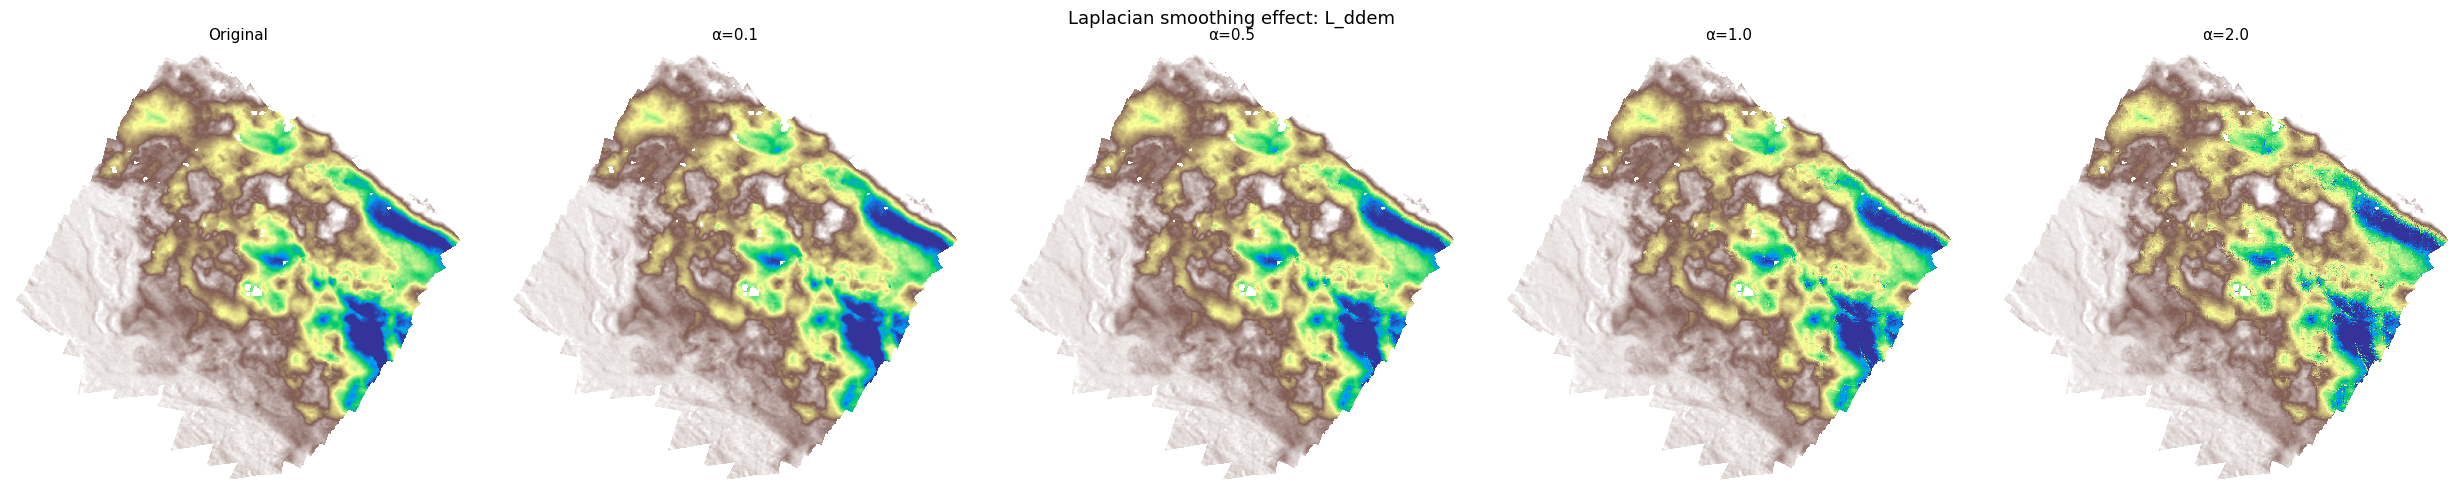

saved smoothing_L_ddem.png


In [36]:
# visualize
visualize_laplacian_smoothing(
    L_ddem, ddem_signal,
    alpha_values=[0.1, 0.5, 1.0, 2.0],
    label='L_ddem',
    valid_r=valid_r, valid_c=valid_c,
    nrows=NROWS, ncols=NCOLS
)

In [37]:
# save valid rows and columns for repeated use
np.save('valid_r.npy', valid_r)
np.save('valid_c.npy', valid_c)
print(f'Saved valid_r.npy, valid_c.npy: {valid_r.shape}')

Saved valid_r.npy, valid_c.npy: (2041172,)


In [38]:
# Architecture decision record -- important for writeup
architecture_notes = {
    'model': 'GRTR-Attention',
    'tensor_layer': 'CPD rank-R, maps (5 spectral x 6 topo) -> d hidden',
    'attention': 'cross-modal, query from hidden, keys/values from (spectral, topo)',
    'membership_head': 'linear -> sigmoid -> k memberships in [0,1]',
    'output_regularization': ['L_elev', 'L_aspect', 'L_ddem'],
    'weight_regularization': 'L_band on spectral factor matrix U2',
    'loss_terms': ['spectral_reconstruction', 'laplacian_smoothness', 'band_smoothness'],
    'constraints': 'box [0,1] via sigmoid, no sum-to-one',
    'justification_papers': ['Konstantinidis2023_GRTR', 'Tucker_unification_paper'],
    'ablations_planned': [
        'remove cross-modal attention',
        'add spectral-spatial L4',
        'vary CPD rank R',
        'vary lambda weights'
    ]
}
np.save('architecture_notes.npy', architecture_notes, allow_pickle=True)
print('Architecture notes saved.')

Architecture notes saved.


In [40]:
### load 7-band mosaic ###
###                    ###

In [41]:
import rasterio
import numpy as np

with rasterio.open('data/CanwellTerminus081325.tif') as src:
    print(f'Driver      : {src.driver}')
    print(f'Shape       : {src.height} rows x {src.width} cols')
    print(f'Bands       : {src.count}')
    print(f'Dtype       : {src.dtypes}')
    print(f'Nodata      : {src.nodata}')
    print(f'CRS         : {src.crs}')
    print(f'Resolution  : {src.res}')
    print()

    # read all 7 bands
    mosaic = src.read() # shape (7, nrows, ncols)
    nodata = src.nodata

print(f'mosaic array shape: {mosaic.shape}')
print()

Driver      : GTiff
Shape       : 1875 rows x 1957 cols
Bands       : 7
Dtype       : ('int16', 'int16', 'int16', 'int16', 'int16', 'int16', 'int16')
Nodata      : -32768.0
CRS         : PROJCS["WGS 84 / UTM zone 6N",GEOGCS["WGS 84",DATUM["World Geodetic System 1984",SPHEROID["WGS 84",6378137,298.257223563]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-147],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
Resolution  : (1.0172394770380195, 1.01723947703739)

mosaic array shape: (7, 1875, 1957)



In [42]:
# Per-band statistics to help identify band order
print(f'{"Band":>5}  {"Min":>10}  {"Max":>10}  {"Mean":>10}  {"Std":>10}')
print('-' * 50)
for b in range(mosaic.shape[0]):
    band = mosaic[b].astype(np.float32)
    if nodata is not None:
        band = band[band != nodata]
    print(f'{b+1:>5}  {band.min():>10.2f}  {band.max():>10.2f}  '
          f'{band.mean():>10.2f}  {band.std():>10.2f}')

 Band         Min         Max        Mean         Std
--------------------------------------------------
    1      455.00    28654.00     7575.49     3852.12
    2      608.00    25915.00     7519.94     3272.54
    3      334.00    28333.00     7645.48     3739.79
    4     1122.00    32209.00    10499.93     3394.60
    5      835.00    27142.00     9849.44     3026.88
    6        0.00    32767.00     6748.58     7680.57
    7    27552.00    29975.00    28993.36      365.02


In [43]:
### verify with band metadata ###
with rasterio.open('data/CanwellTerminus081325.tif') as src:
    print('Band descriptions:')
    for i, desc in enumerate(src.descriptions):
        print(f'  Band {i+1}: {desc}')
    print()
    print('Band color interpretations:')
    for i in range(src.count):
        print(f'  Band {i+1}: {src.colorinterp[i]}')
    print()
    # Check for wavelength metadata in tags
    tags = src.tags()
    print(f'Dataset tags: {tags}')
    for i in range(1, src.count+1):
        btags = src.tags(i)
        if btags:
            print(f'  Band {i} tags: {btags}')

Band descriptions:
  Band 1: None
  Band 2: None
  Band 3: None
  Band 4: None
  Band 5: None
  Band 6: None
  Band 7: None

Band color interpretations:
  Band 1: 1
  Band 2: 0
  Band 3: 0
  Band 4: 0
  Band 5: 0
  Band 6: 0
  Band 7: 0

Dataset tags: {'DataType': 'Generic', 'AREA_OR_POINT': 'Area'}
  Band 1 tags: {'RepresentationType': 'ATHEMATIC', 'STATISTICS_MAXIMUM': '28654', 'STATISTICS_MEAN': '7575.4849252635', 'STATISTICS_MINIMUM': '455', 'STATISTICS_STDDEV': '3852.1238298882', 'STATISTICS_VALID_PERCENT': '54.22'}
  Band 2 tags: {'RepresentationType': 'ATHEMATIC', 'STATISTICS_MAXIMUM': '25915', 'STATISTICS_MEAN': '7519.9371492675', 'STATISTICS_MINIMUM': '608', 'STATISTICS_STDDEV': '3272.5387316962', 'STATISTICS_VALID_PERCENT': '54.22'}
  Band 3 tags: {'RepresentationType': 'ATHEMATIC', 'STATISTICS_MAXIMUM': '28333', 'STATISTICS_MEAN': '7645.4817698352', 'STATISTICS_MINIMUM': '334', 'STATISTICS_STDDEV': '3739.7904486369', 'STATISTICS_VALID_PERCENT': '54.22'}
  Band 4 tags: {'Repr

In [45]:
band6 = mosaic[6].astype(np.float32)
band6 = band6[band6 != 0]
print(f'{b:>5}  {band.min():>10.2f}  {band.max():>10.2f}  '
      f'{band.mean():>10.2f}  {band.std():>10.2f}')

    6    27552.00    29975.00    28993.36      365.02


In [48]:
### verify bands 6 and 7 ###
### as identical or not  ###

In [50]:
# Extract bands 6 and 7 over valid pixels only
# Mask band 6 nodata (0) first
b6 = mosaic[5, valid_r, valid_c].copy()
b7 = mosaic[6, valid_r, valid_c].copy()

#b6[b6 == 0] = np.nan

# How many valid pixels in each?
print(f'Band 6 valid pixels: {(~np.isnan(b6)).sum():,}')
print(f'Band 7 valid pixels: {(~np.isnan(b7)).sum():,}')
print()

# Direct difference where both are valid
both_valid = (~np.isnan(b6)) & (~np.isnan(b7))
diff = b6[both_valid] - b7[both_valid]

print(f'Pixels where both valid: {both_valid.sum():,}')
print(f'Difference stats:')
print(f'  Min  : {diff.min():.4f}')
print(f'  Max  : {diff.max():.4f}')
print(f'  Mean : {diff.mean():.4f}')
print(f'  Std  : {diff.std():.4f}')
print(f'  Identical pixels (diff==0): {(diff == 0).sum():,}')
print()

Band 6 valid pixels: 2,041,172
Band 7 valid pixels: 2,041,172

Pixels where both valid: 2,041,172
Difference stats:
  Min  : -32768.0000
  Max  : 4150.0000
  Mean : -16972.7684
  Std  : 6518.9206
  Identical pixels (diff==0): 7



In [52]:
b6_raw = mosaic[5, valid_r, valid_c].copy()

print('Band 6 raw statistics (no masking):')
print(f'  Min  : {np.nanmin(b6_raw):.2f}')
print(f'  Max  : {np.nanmax(b6_raw):.2f}')
print(f'  Mean : {np.nanmean(b6_raw):.2f}')
print(f'  Std  : {np.nanstd(b6_raw):.2f}')
print()

# Distribution of values -- look for nodata clusters
print('Value distribution (percentiles):')
for p in [0.1, 1, 5, 10, 25, 50, 75, 90, 95, 99, 99.9]:
    print(f'  p{p:>5.1f}: {np.nanpercentile(b6_raw, p):>10.2f}')
print()

# Check for suspicious value clusters that might be nodata
print(f'Pixels with value <= 0    : {(b6_raw <= 0).sum():,}')
print(f'Pixels with value < 100   : {(b6_raw < 100).sum():,}')
print(f'Pixels with value == -32768: {(b6_raw == -32768).sum():,}')

Band 6 raw statistics (no masking):
  Min  : 0.00
  Max  : 32767.00
  Mean : 12118.43
  Std  : 6383.00

Value distribution (percentiles):
  p  0.1:       0.00
  p  1.0:       0.00
  p  5.0:    4089.00
  p 10.0:    5737.00
  p 25.0:    7987.00
  p 50.0:   10588.00
  p 75.0:   15097.00
  p 90.0:   21743.00
  p 95.0:   25304.00
  p 99.0:   30782.00
  p 99.9:   32767.00

Pixels with value <= 0    : 52,926
Pixels with value < 100   : 52,928
Pixels with value == -32768: 0


In [46]:
### extract valid node spectral arrays ###
###                                    ###

In [54]:
with rasterio.open('data/CanwellTerminus081325.tif') as src:
    mosaic = src.read().astype(np.float32) # shape (7, rows, cols)
    nodata = src.nodata

print(f'mosaic shape: {mosaic.shape}')
print(f'nodata value: {nodata}')
print()

# replace global nodata with nan
if nodata is not None:
    mosaic[mosaic == nodata] = np.nan

# extract all 7 bands at valid node positions
spectral_nodes = np.stack([
    mosaic[b, valid_r, valid_c] for b in range(7)
], axis=1) # shape (N,7)

print(f'spectral_nodes shape: {spectral_nodes.shape}')
print

band_names = ['blue', 'green', 'red', 'rededge', 'NIR', 'panchromatic', 'LWIR']
print(f'{"Band":>12}  {"Min":>10}  {"Max":>10}  {"Mean":>10}  {"Std":>10}  {"NaNs":>8}')
print('-' * 66)
for i, name in enumerate(band_names):
    col = spectral_nodes[:,i]
    nans = np.isnan(col).sum()
    valid = col[~np.isnan(col)]
    print(f'{name:>12}  {valid.min():>10.2f}  {valid.max():>10.2f}  '
          f'{valid.mean():>10.2f}  {valid.std():>10.2f}  {nans:>8,}')

# split into spectral (1-5) and auxillary (6-7) bands
spectral5_arr = spectral_nodes[:, :5] # blue, green, red, rededge, NIR
aux2bands_arr = spectral_nodes[:, 5:] # panchromatic, LWIR

print()
print(f'spectral5 shape: {spectral5_arr.shape}')
print(f'aux2bands shape: {aux2bands_arr.shape}')

mosaic shape: (7, 1875, 1957)
nodata value: -32768.0

spectral_nodes shape: (2041172, 7)
        Band         Min         Max        Mean         Std      NaNs
------------------------------------------------------------------
        blue      455.00    28654.00     7578.16     3851.44    52,926
       green      608.00    25915.00     7521.80     3272.49    52,926
         red      334.00    28333.00     7648.15     3739.10    52,926
     rededge     1122.00    32209.00    10500.55     3395.09    52,926
         NIR      835.00    27142.00     9848.86     3026.70    52,926
panchromatic        0.00    32767.00    12118.43     6383.00         0
        LWIR    27552.00    29975.00    28993.32      365.09    52,926

spectral5 shape: (2041172, 5)
aux2bands shape: (2041172, 2)


NaN pixels: 52,926


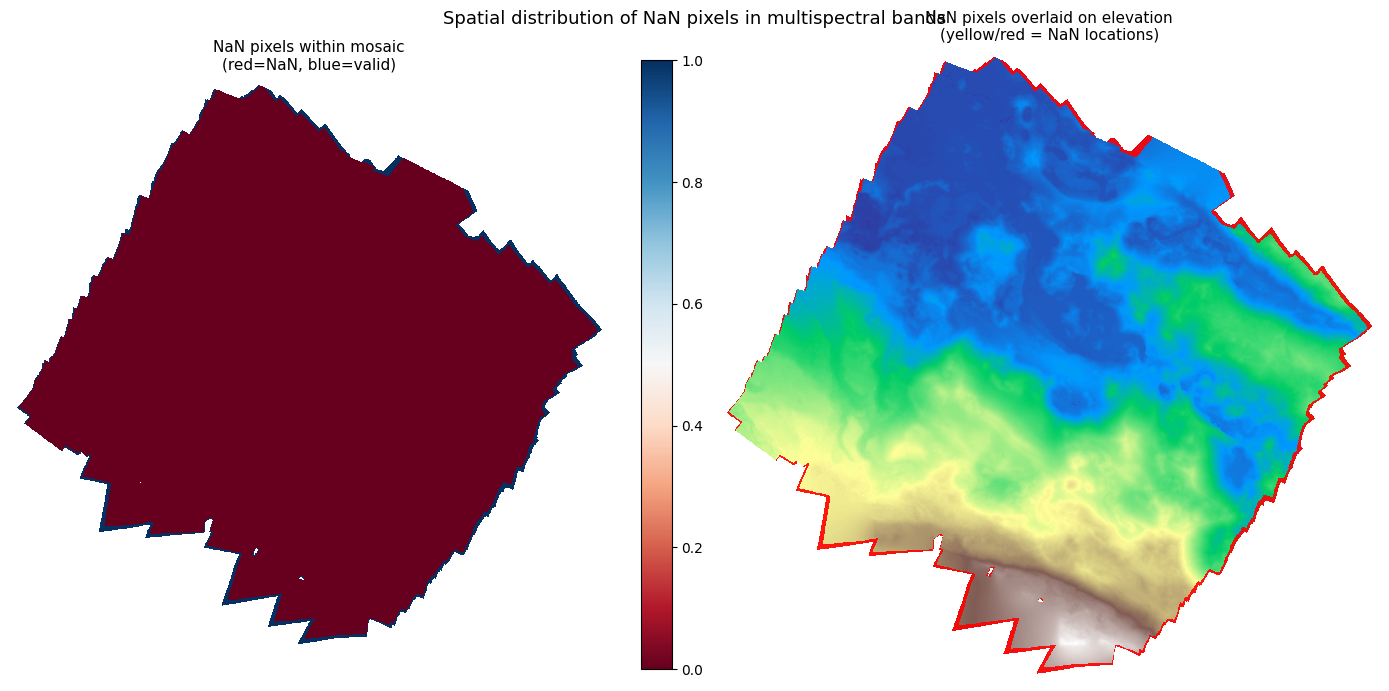

Saved nan_mask_spatial.png


In [56]:
water_candidate = np.isnan(spectral5_arr[:, 0])
print(f'NaN pixels: {water_candidate.sum():,}')

# Build canvases
nan_canvas  = np.full((NROWS, NCOLS), np.nan)
elev_canvas = np.full((NROWS, NCOLS), np.nan)

nan_canvas[valid_r, valid_c]  = water_candidate.astype(np.float32)
elev_canvas[valid_r, valid_c] = arr[:, 0]

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# Left: NaN mask alone -- only show pixels inside mosaic
# 0 = valid multispectral, 1 = NaN
im0 = axes[0].imshow(nan_canvas, cmap='RdBu',
                     vmin=0, vmax=1,
                     interpolation='nearest')
axes[0].set_title('NaN pixels within mosaic\n(red=NaN, blue=valid)', fontsize=11)
axes[0].axis('off')
plt.colorbar(im0, ax=axes[0], fraction=0.046)

# Right: elevation base with NaN pixels highlighted in bright yellow
axes[1].imshow(elev_canvas, cmap='terrain', interpolation='nearest')

# Create a masked array that is only non-nan where water_candidate is True
highlight = np.where(nan_canvas == 1, 1.0, np.nan)
axes[1].imshow(highlight, cmap='autumn',
               interpolation='nearest', alpha=0.9)
axes[1].set_title('NaN pixels overlaid on elevation\n(yellow/red = NaN locations)',
                  fontsize=11)
axes[1].axis('off')

plt.suptitle('Spatial distribution of NaN pixels in multispectral bands', fontsize=13)
plt.tight_layout()
#plt.savefig('nan_mask_spatial.png', dpi=120, bbox_inches='tight')
plt.show()
#print('Saved nan_mask_spatial.png')

In [58]:
### prepare to exclude fringe pixels from training ###
## but include their valid topographic data for regularizing ###
## this mask will be used in the loss function
## compute reconstruction loss only over valid spectral pixels
## laplacian regularization still over all N nodes
# True where all 5 spectral bands are valid
spectral_valid_mask = ~np.isnan(spectral5_arr).any(axis=1)

N = spectral_valid_mask.shape[0]

print(f'Total nodes              : {N:,}')
print(f'Spectrally valid nodes   : {spectral_valid_mask.sum():,}')
print(f'Boundary fringe excluded : {(~spectral_valid_mask).sum():,}')
print(f'Valid fraction           : {100*spectral_valid_mask.mean():.2f}%')

Total nodes              : 2,041,172
Spectrally valid nodes   : 1,988,246
Boundary fringe excluded : 52,926
Valid fraction           : 97.41%


In [59]:
### save spectral arrays and spectral mask ###

# spectral arrays
np.save('spectral5_arr.npy', spectral5_arr)
np.save('aux2bands_arr.npy', aux2bands_arr)
np.save('spectral_valid_mask.npy', spectral_valid_mask)

print('saved')

print(f'  spectral5_arr.npy      : {spectral5_arr.shape}  float32')
print(f'  aux2bands_arr.npy      : {aux2bands_arr.shape}  float32')
print(f'  spectral_valid_mask.npy: {spectral_valid_mask.shape}  bool')
print()

saved
  spectral5_arr.npy      : (2041172, 5)  float32
  aux2bands_arr.npy      : (2041172, 2)  float32
  spectral_valid_mask.npy: (2041172,)  bool



In [61]:
# Confirm what we now have on disk
import os
files = [
    'L_elev.npz', 'L_aspect.npz', 'L_ddem.npz',
    'edge_i.npy', 'edge_j.npy',
    'ddem_nodes.npy', 'valid_r.npy', 'valid_c.npy',
    'spectral5_arr.npy', 'aux2bands_arr.npy',
    'spectral_valid_mask.npy',
    'beta_params.npy'
]
print('Current saved files:')
for f in files:
    filename = 'data/' + f
    if os.path.exists(filename):
        size_mb = os.path.getsize(filename) / 1e6
        print(f'  {filename:<35} {size_mb:>8.1f} MB')
    else:
        print(f'  {filename:<35}  MISSING')

Current saved files:
  data/L_elev.npz                         85.6 MB
  data/L_aspect.npz                       83.8 MB
  data/L_ddem.npz                         85.6 MB
  data/edge_i.npy                         65.2 MB
  data/edge_j.npy                         65.2 MB
  data/ddem_nodes.npy                      8.2 MB
  data/valid_r.npy                        16.3 MB
  data/valid_c.npy                        16.3 MB
  data/spectral5_arr.npy                  40.8 MB
  data/aux2bands_arr.npy                  16.3 MB
  data/spectral_valid_mask.npy             2.0 MB
  data/beta_params.npy                     0.0 MB


In [3]:
### endmembers preparation ###
###                        ###

import pandas as pd

em_df = pd.read_csv('data/canwell_endmembers_selected.csv')

print(f'Shape: {em_df.shape}')
print(f'Columns: {em_df.columns.tolist()}')
print()
print(em_df[['filename', 'material', 'spectrometer']].to_string())
print()

# Extract the 5-band matrix
band_cols = ['Blue_475', 'Green_560', 'Red_668', 'RedEdge_717', 'NIR_842']
E = em_df[band_cols].values.astype(np.float32)

print(f'E shape: {E.shape}  (endmembers x bands)')
print()
print(f'Reflectance range: [{E.min():.4f}, {E.max():.4f}]')
print(f'Any NaNs: {np.isnan(E).sum()}')

Shape: (21, 8)
Columns: ['filename', 'material', 'spectrometer', 'Blue_475', 'Green_560', 'Red_668', 'RedEdge_717', 'NIR_842']

                                                 filename                material spectrometer
0             splib07a_Hornblende_HS16.3B_ASDFRb_AREF.txt              Hornblende          ASD
1             splib07a_Muscovite_HS146.3B_ASDFRa_AREF.txt               Muscovite          ASD
2   splib07a_Engelmann-Spruce_ES-Needls-1_ASDFRa_AREF.txt        Engelmann-Spruce          ASD
3       splib07a_Epidote_GDS26.a_75-200um_ASDNGb_AREF.txt                 Epidote          ASD
4    splib07a_Goeth+qtz.5+Jarosite.5_AMX11_BECKb_AREF.txt  Goeth+qtz.5+Jarosite.5         BECK
5    splib07a_Goethite_Phyllite_CU91-236A_ASDFRb_AREF.txt                Goethite          ASD
6        splib07a_Grass_Golden_Dry_GDS480_ASDFRa_AREF.txt                   Grass          ASD
7      splib07a_Jarosite_Rhyolite_CU91-20A_BECKa_AREF.txt                Jarosite         BECK
8            spli

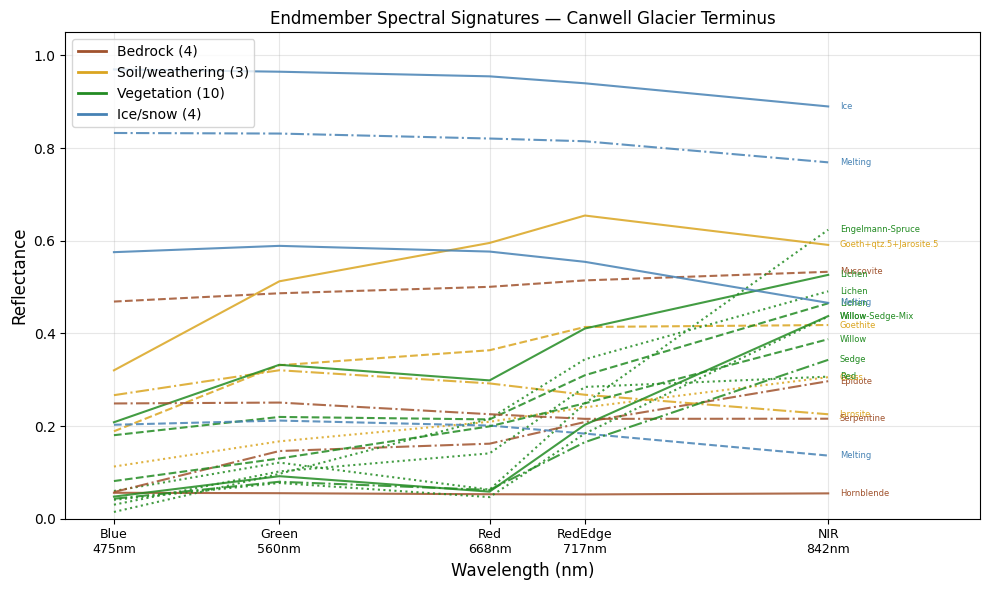

Saved endmember_spectra.png


In [4]:
### visualize endmember spectra ###

band_cols   = ['Blue_475', 'Green_560', 'Red_668', 'RedEdge_717', 'NIR_842']
band_names  = ['Blue\n475nm', 'Green\n560nm', 'Red\n668nm', 'RedEdge\n717nm', 'NIR\n842nm']
wavelengths = [475, 560, 668, 717, 842]

E = em_df[band_cols].values.astype(np.float32)

# Group colors by category
category_colors = {
    'bedrock'    : 'sienna',
    'soil'       : 'goldenrod',
    'vegetation' : 'forestgreen',
    'snow_ice'   : 'steelblue',
}

def get_category(material):
    m = material.lower()
    if any(x in m for x in ['hornblende', 'muscovite', 'epidote', 'serpentine']):
        return 'bedrock'
    if any(x in m for x in ['goeth', 'jarosite', 'grass']):
        return 'soil'
    if any(x in m for x in ['spruce', 'willow', 'sedge', 'lichen', 'red', 'algea']):
        return 'vegetation'
    if any(x in m for x in ['melting', 'ice', 'slush', 'snow']):
        return 'snow_ice'
    return 'soil'

fig, ax = plt.subplots(figsize=(10, 6))

for i, row in em_df.iterrows():
    cat   = get_category(row['material'])
    color = category_colors[cat]
    label = row['material']
    # Distinguish duplicates by linestyle
    ls = ['-', '--', ':', '-.'][i % 4]
    ax.plot(wavelengths, E[i], color=color, linestyle=ls,
            linewidth=1.5, alpha=0.85, label=label)
    # Label at NIR end
    ax.annotate(label, xy=(842, E[i, 4]),
                xytext=(848, E[i, 4]),
                fontsize=6, color=color, va='center')

ax.set_xlabel('Wavelength (nm)', fontsize=12)
ax.set_ylabel('Reflectance', fontsize=12)
ax.set_title('Endmember Spectral Signatures — Canwell Glacier Terminus', fontsize=12)
ax.set_xticks(wavelengths)
ax.set_xticklabels(band_names, fontsize=9)
ax.set_xlim(450, 920)
ax.set_ylim(0, 1.05)
ax.grid(alpha=0.3)

# Legend by category only
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='sienna',      lw=2, label='Bedrock (4)'),
    Line2D([0], [0], color='goldenrod',   lw=2, label='Soil/weathering (3)'),
    Line2D([0], [0], color='forestgreen', lw=2, label='Vegetation (10)'),
    Line2D([0], [0], color='steelblue',   lw=2, label='Ice/snow (4)'),
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=10)

plt.tight_layout()
plt.savefig('endmember_spectra.png', dpi=130, bbox_inches='tight')
plt.show()
print('Saved endmember_spectra.png')

In [5]:
### convert spectral arrays to reflectance ###
###                                        ###

In [6]:
spectral5_arr = np.load('data/spectral5_arr.npy')

In [7]:
aux2bands_arr = np.load('data/aux2bands_arr.npy')

In [10]:
spectral_valid_mask = np.load('data/spectral_valid_mask.npy')

In [8]:
# from https://agisoft.freshdesk.com/support/solutions/articles/31000148381-micasense-altum-processing-workflow-including-reflectance-calibration-in-agisoft-metashape-professi
REFLECTANCE_SCALE = 32768.0

# convert spectrals 1-5 to reflectance
spectral5_refl = spectral5_arr / REFLECTANCE_SCALE

# panchromatic (band 6) also calibrated -- convert
panc_refl = aux2bands_arr[:,0] / REFLECTANCE_SCALE

# LWIR (band 7) NOT reflectance calibrated -- leave raw
# but normalize during feature scaling
lwir_raw = aux2bands_arr[:,1] # keep as-is for now

print(f'reflectance scale factor: {REFLECTANCE_SCALE}')
print()


reflectance scale factor: 32768.0



In [12]:
# print stats of scaled reflectance bands

band_names = ['Blue', 'Green', 'Red', 'RedEdge', 'NIR']
print(f'{"Band":>10}  {"Min":>8}  {"Max":>8}  {"Mean":>8}  {"Std":>8}')
print('-' * 50)
for i, name in enumerate(band_names):
    col = spectral5_refl[spectral_valid_mask, i]
    print(f'{name:>10}  {col.min():>8.4f}  {col.max():>8.4f}  '
          f'{col.mean():>8.4f}  {col.std():>8.4f}')

print()
col = panc_refl[spectral_valid_mask]
print(f'{"Panc":>10}  {col.min():>8.4f}  {col.max():>8.4f}  '
      f'{col.mean():>8.4f}  {col.std():>8.4f}')
print()
col = lwir_raw[spectral_valid_mask]
print(f'{"LWIR(DN)":>10}  {col.min():>8.1f}  {col.max():>8.1f}  '
      f'{col.mean():>8.1f}  {col.std():>8.1f}')
print()

      Band       Min       Max      Mean       Std
--------------------------------------------------
      Blue    0.0139    0.8745    0.2313    0.1175
     Green    0.0186    0.7909    0.2295    0.0999
       Red    0.0102    0.8647    0.2334    0.1141
   RedEdge    0.0342    0.9829    0.3205    0.1036
       NIR    0.0255    0.8283    0.3006    0.0924

      Panc    0.0017    1.0000    0.3797    0.1877

  LWIR(DN)   27552.0   29975.0   28993.3     365.1



In [13]:
# Verify endmember matrix is already in reflectance [0,1]
print(f'E reflectance range: [{E.min():.4f}, {E.max():.4f}] -- should be in [0,1]')
print()
print('spectral5_refl and E are now in the same reflectance space.')

E reflectance range: [0.0146, 0.9700] -- should be in [0,1]

spectral5_refl and E are now in the same reflectance space.


In [15]:
### build normalized spectral matrix for tensor layer ###
# note: loss reconstruction = ||R - A·Eᵀ||²
# R:=Nx5 spectral matrix, E:= 21x5 endmember matrix (both fixed)
# A:= Nx21 fuzzy membership matrix (learned)
# R and E are UNNORMALIZED and in the same reflectance units
# to be physically meaningful

# however, the TENSOR LAYER takes all features (spectral + topo) at each pixel
# and maps them to a hidden layer 
# (spectral, topographic) → hidden → memberships
# this requires spectral bands (1-7) and topographic features (elev, slope... log_acc)
# to all be normalized

# the architecture separates these uses cleanly:

# spectral5_refl (raw)  ──────────────────────────► reconstruction loss
#                                                   ||R - A·Eᵀ||²
# spectral5_refl (normalized) ──┐
# topo features (normalized)  ──┤► tensor layer ──► A ──► spatial loss
# panchromatic (normalized)   ──┤                        λ·tr(AᵀLA)
# lwir (normalized)           ──┘

# normalized version helps network learn efficiently
# raw version ensures reconstruction loss has physical meaning

In [16]:
# compute normalization stats from spectrally valid pixels only
# to avoid boundary fringe (nodata) pixels from biasing the statistics

def zscore_normalize(data, mask, name):
    """
    z-score normalize columns of data using statistics from valid rows
    returns normalized array and (mean, std) for each column
    """
    valid_data = data[mask]
    mu = valid_data.mean(axis=0)
    std = valid_data.std(axis=0)
    std = np.where(std > 1e-8, std, 1.0) # avoid division by zero
    normalized = (data - mu) / std
    print(f'{name}: mu=[{mu.min():.4f}..{mu.max():.4f}]  '
          f'std=[{std.min():.4f}..{std.max():.4f}]')
    return normalized.astype(np.float32), mu, std

In [18]:
print('normalizing features for tensor layer input')
print()

# Spectral 5 bands
spec_norm, spec_mu, spec_std = zscore_normalize(
    spectral5_refl, spectral_valid_mask, 'spectral5'
)

# Topographic features (elevation, slope, asin, acos, curvature, log_accum)
topo_norm, topo_mu, topo_std = zscore_normalize(
    arr.astype(np.float32), spectral_valid_mask, 'topo6   '
)

# Panchromatic
panc_col = panc_refl.reshape(-1, 1)
panc_norm, panc_mu, panc_std = zscore_normalize(
    panc_col, spectral_valid_mask, 'panc    '
)

# LWIR
lwir_col = lwir_raw.reshape(-1, 1).astype(np.float32)
lwir_norm, lwir_mu, lwir_std = zscore_normalize(
    lwir_col, spectral_valid_mask, 'lwir    '
)

normalizing features for tensor layer input

spectral5: mu=[0.2295..0.3205]  std=[0.0923..0.1174]
topo6   : mu=[-0.0123..860.8915]  std=[0.0531..38.2662]
panc    : mu=[0.3797..0.3797]  std=[0.1877..0.1877]
lwir    : mu=[28993.3184..28993.3184]  std=[365.0926..365.0926]


In [19]:
# concatenate into full feature matrix for tensor layer
# shape (N,13): 5 spectral, 6 topo, 1 panc, 1 lwir
X_norm = np.concatenate([
    spec_norm, # cols 0-4 spectral
    topo_norm, # cols 5-10 topographic
    panc_norm, # col 11 panchromatic
    lwir_norm  # col 12 LWIR
], axis=1)
print()
print(f'X_norm shape: {X_norm.shape}  (N x 13 features)')
print(f'X_norm dtype: {X_norm.dtype}')
print()


X_norm shape: (2041172, 13)  (N x 13 features)
X_norm dtype: float32



In [20]:
# Verify normalization worked -- valid pixels should have ~0 mean, ~1 std
valid_X = X_norm[spectral_valid_mask]
print('Verification (valid pixels only):')
print(f'  Column means: min={valid_X.mean(axis=0).min():.4f}  '
      f'max={valid_X.mean(axis=0).max():.4f}  (should be ~0)')
print(f'  Column stds : min={valid_X.std(axis=0).min():.4f}  '
      f'max={valid_X.std(axis=0).max():.4f}  (should be ~1)')

Verification (valid pixels only):
  Column means: min=-0.0032  max=0.0030  (should be ~0)
  Column stds : min=0.9992  max=1.0002  (should be ~1)


In [22]:
# save normalized feature matrix
np.save('data/X_norm.npy', X_norm)

# save raw reflectance arrays for reconstruction loss
np.save('data/spec5refl_R.npy', spectral5_refl)

# save normalization parameters -- essential for inference on new data
norm_params = {
    'spectral_mu':  spec_mu,
    'spectral_std': spec_std,
    'topo_mu':      topo_mu,
    'topo_std':     topo_std,
    'panc_mu':      panc_mu,
    'panc_std':     panc_std,
    'lwir_mu':      lwir_mu,
    'lwir_std':     lwir_std,
    'reflectance_scale': 32768.0,
    'feature_order': [
        'Blue_475', 'Green_560', 'Red_668', 'RedEdge_717', 'NIR_842',
        'elevation', 'slope', 'aspect_sin', 'aspect_cos',
        'curvature', 'log_accum', 'panchromatic', 'lwir'
    ]
}
np.save('data/norm_params.npy', norm_params, allow_pickle=True)

# save endmember matrix with labels
np.save('data/endmem21_E.npy', E)
em_df.to_csv('data/endmembers_final.csv', index=False)

print('Saved:')
print(f'  data/X_norm.npy           {X_norm.nbytes/1e6:.1f} MB')
print(f'  data/spec5refl_R.npy   {spectral5_refl.nbytes/1e6:.1f} MB')
print(f'  data/norm_params.npy')
print(f'  data/endmem21_E.npy                {E.nbytes/1e6:.3f} MB')
print(f'  data/endmembers_final.csv')

Saved:
  data/X_norm.npy           106.1 MB
  data/spec5refl_R.npy   40.8 MB
  data/norm_params.npy
  data/endmem21_E.npy                0.000 MB
  data/endmembers_final.csv


In [23]:
### build L_band ###
### compute empirical correlation matrix from valid pixels ###
# raw reflectance -- correlation structure should reflect
# physical band relationships, not normalized artifacts

R_valid = spectral5_refl[spectral_valid_mask] # shape (1988246, 5)

# center each band
R_centered = R_valid - R_valid.mean(axis=0)

# correlation matrix
std = R_valid.std(axis=0)
C = (R_centered.T @ R_centered) / (R_valid.shape[0] -1)
C = C / (std[:, None] * std[None, :])

band_names_short = ['blue','green','red','rededge','NIR']
print('band correlation matrix:')
print(f'{"":>8}', end='')
for name in band_names_short:
    print(f'{name:>10}', end='')
print()
for i, name in enumerate(band_names_short):
    print(f'{name:>8}', end='')
    for j in range(5):
        print(f'{C[i,j]:>10.4f}', end='')
    print()
print()

band correlation matrix:
              blue     green       red   rededge       NIR
    blue    1.0018    0.9734    0.9901    0.8188    0.4118
   green    0.9734    1.0013    0.9787    0.8872    0.5862
     red    0.9901    0.9787    1.0018    0.8427    0.4774
 rededge    0.8188    0.8872    0.8427    1.0020    0.7025
     NIR    0.4118    0.5862    0.4774    0.7025    1.0013



In [26]:
# edge weights from correlation -- high corr = strong connection
# use corr directly as weights (already in [0,1] for positive corr)
# negative correlations set to 0 -- disconnected in the graph
W_5band = np.maximum(C,0).astype(np.float32)
np.fill_diagonal(W_5band, 0) # no self-loops

print('(final) 5-band adjacency weights (W_5band):')
print(f'{"":>8}', end='')
for name in band_names_short:
    print(f'{name:>10}', end='')
print()
for i, name in enumerate(band_names_short):
    print(f'{name:>8}', end='')
    for j in range(5):
        print(f'{W_5band[i,j]:>10.4f}', end='')
    print()

(final) 5-band adjacency weights (W_5band):
              blue     green       red   rededge       NIR
    blue    0.0000    0.9734    0.9901    0.8188    0.4118
   green    0.9734    0.0000    0.9787    0.8872    0.5862
     red    0.9901    0.9787    0.0000    0.8427    0.4774
 rededge    0.8188    0.8872    0.8427    0.0000    0.7025
     NIR    0.4118    0.5862    0.4774    0.7025    0.0000


In [27]:
### build L_band from W_5band ###
# build normalized laplacian from 5x5 adjacency matrix
# same formula as spatial laplacians but tiny - use dense computation

W = W_5band.copy()

# degree vector
d = W.sum(axis=1)
print(f'band degrees: {d.round(4)}')
print()

# D^{-1/2}
d_invsqrt = 1.0 / np.sqrt(d)
D_invsqrt = np.diag(d_invsqrt)

# normalized laplacian L = I - D^{-1/2} W D^{-1/2}
L_band = np.eye(5) - D_invsqrt @ W @ D_invsqrt

print('L_band (5x5 normalized Laplacian):')
print(f'{"":>8}', end='')
for name in band_names_short:
    print(f'{name:>10}', end='')
print()
for i, name in enumerate(band_names_short):
    print(f'{name:>8}', end='')
    for j in range(5):
        print(f'{L_band[i,j]:>10.4f}', end='')
    print()

print()

# Verify properties
eigenvalues = np.linalg.eigvalsh(L_band)
print(f'Eigenvalues: {eigenvalues.round(6)}')
print(f'Min eigenvalue: {eigenvalues.min():.6f}  (should be >= 0)')
print(f'Max eigenvalue: {eigenvalues.max():.6f}  (should be <= 2)')
print(f'Symmetry check: {np.abs(L_band - L_band.T).max():.2e}  (should be ~0)')

band degrees: [3.1941 3.4255 3.2889 3.2513 2.1779]

L_band (5x5 normalized Laplacian):
              blue     green       red   rededge       NIR
    blue    1.0000   -0.2943   -0.3055   -0.2541   -0.1561
   green   -0.2943    1.0000   -0.2916   -0.2659   -0.2146
     red   -0.3055   -0.2916    1.0000   -0.2577   -0.1784
 rededge   -0.2541   -0.2659   -0.2577    1.0000   -0.2640
     NIR   -0.1561   -0.2146   -0.1784   -0.2640    1.0000

Eigenvalues: [0.       1.108723 1.281164 1.298438 1.311675]
Min eigenvalue: 0.000000  (should be >= 0)
Max eigenvalue: 1.311675  (should be <= 2)
Symmetry check: 2.98e-08  (should be ~0)


In [28]:
# save
np.save('data/L_band.npy', L_band)
print()
print('Saved data/L_band.npy')


Saved data/L_band.npy


In [30]:
###### end pre-processing -- move to training notebook ######
######                                                 ######